In [1]:
# ============================================================
# TUTORIAL: Semi-Supervised vs Supervised Learning
# Dataset: Breast Cancer Wisconsin (Diagnostic)
# ============================================================

In [2]:
# ============================================================
# SECTION 1: IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# ============================================================
# SECTION 2: LOAD AND EXPLORE DATASET
# ============================================================
data = load_breast_cancer()
X    = data.data
y    = data.target

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total samples      : {X.shape[0]}")
print(f"Total features     : {X.shape[1]}")
print(f"Classes            : {list(data.target_names)}")
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  {data.target_names[cls]} ({cls})  : {cnt} samples "
          f"({cnt/len(y)*100:.1f}%)")

DATASET OVERVIEW
Total samples      : 569
Total features     : 30
Classes            : ['malignant', 'benign']
  malignant (0)  : 212 samples (37.3%)
  benign (1)  : 357 samples (62.7%)


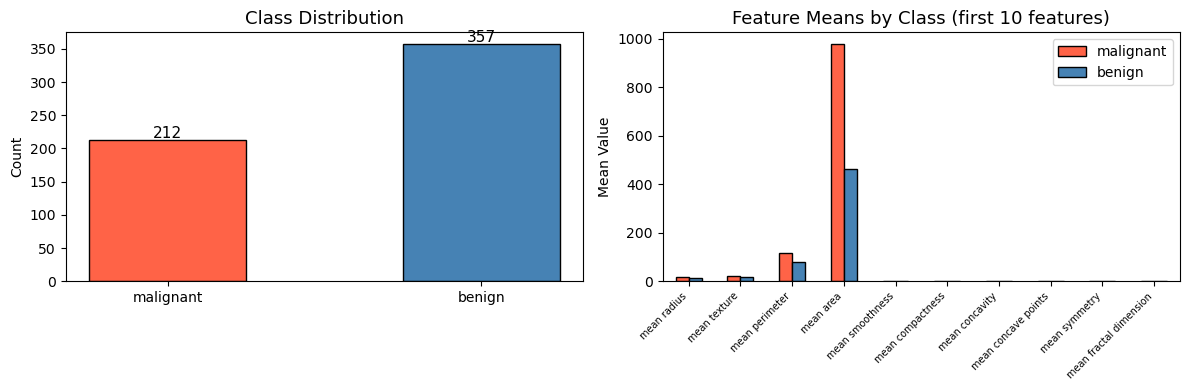

In [4]:
# --- Plot: class distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(data.target_names, counts, color=['tomato', 'steelblue'],
            edgecolor='black', width=0.5)
axes[0].set_title("Class Distribution", fontsize=13)
axes[0].set_ylabel("Count")
for i, cnt in enumerate(counts):
    axes[0].text(i, cnt + 3, str(cnt), ha='center', fontsize=11)

# Feature means by class
df = pd.DataFrame(X, columns=data.feature_names)
df['label'] = y
means = df.groupby('label').mean().T.iloc[:10]  # first 10 features
means.columns = data.target_names
means.plot(kind='bar', ax=axes[1], color=['tomato', 'steelblue'],
           edgecolor='black')
axes[1].set_title("Feature Means by Class (first 10 features)", fontsize=13)
axes[1].set_ylabel("Mean Value")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right',
                         fontsize=7)
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# SECTION 3: TRAIN / TEST SPLIT + SCALING
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}\n")

Training samples : 455
Test samples     : 114



In [6]:
# ============================================================
# SECTION 4: HELPER — CREATE LIMITED LABEL SCENARIO
# ============================================================
def create_limited_labels(y_train, label_fraction, random_state=42):
    """
    Keep only `label_fraction` of training labels.
    Remaining labels are set to -1 (unlabelled convention in sklearn).
    """
    rng       = np.random.RandomState(random_state)
    y_limited = y_train.copy().astype(int)

    n_labelled   = max(int(len(y_train) * label_fraction), 2)
    labelled_idx = rng.choice(len(y_train), size=n_labelled, replace=False)

    mask        = np.zeros(len(y_train), dtype=bool)
    mask[labelled_idx] = True
    y_limited[~mask]   = -1

    return y_limited

In [7]:
# ============================================================
# SECTION 5: HELPER — METRICS PRINTER
# ============================================================
def print_metrics(y_test, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print(classification_report(y_test, y_pred,
                                 target_names=data.target_names))

In [8]:
# ============================================================
# ============================================================
# MODEL A: SUPERVISED LEARNING BASELINE (100% labels)
# ============================================================
# ============================================================
print("=" * 60)
print("MODEL A: SUPERVISED LEARNING — FULL LABELS (100%)")
print("=" * 60)

# --- Train ---
rf_full = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_full.fit(X_train_scaled, y_train)

# --- Evaluate ---
y_pred_full   = rf_full.predict(X_test_scaled)
y_proba_full  = rf_full.predict_proba(X_test_scaled)[:, 1]
acc_full      = accuracy_score(y_test, y_pred_full)
print_metrics(y_test, y_pred_full, "Supervised — 100% labels")

MODEL A: SUPERVISED LEARNING — FULL LABELS (100%)

--- Supervised — 100% labels ---
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



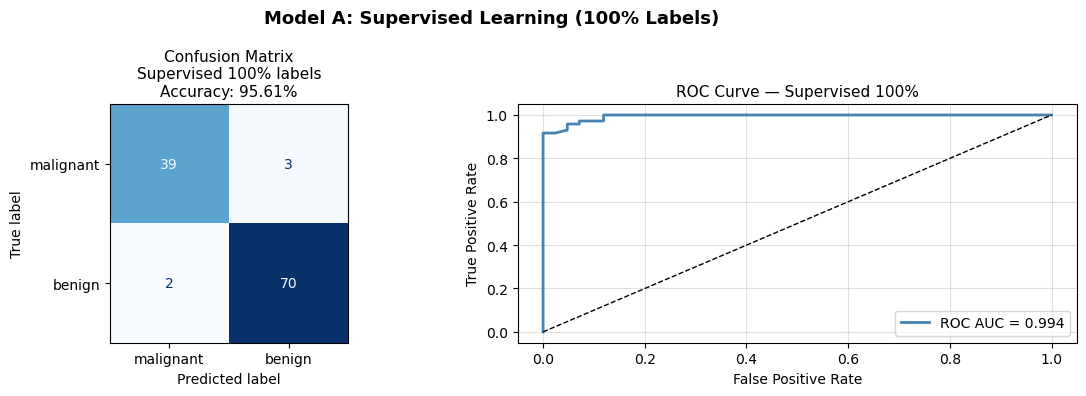

In [9]:
# --- Visualise: Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_full = confusion_matrix(y_test, y_pred_full)
disp    = ConfusionMatrixDisplay(cm_full, display_labels=data.target_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f"Confusion Matrix\nSupervised 100% labels\n"
                  f"Accuracy: {acc_full*100:.2f}%", fontsize=11)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_full)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'ROC AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — Supervised 100%", fontsize=11)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.4)

plt.suptitle("Model A: Supervised Learning (100% Labels)", fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# ============================================================
# MODEL B: SUPERVISED LEARNING — LIMITED LABELS (20%)
# ============================================================
# ============================================================
print("=" * 60)
print("MODEL B: SUPERVISED LEARNING — LIMITED LABELS (20%)")
print("=" * 60)

LABEL_FRAC       = 0.20
y_limited_20     = create_limited_labels(y_train, LABEL_FRAC)

# Use ONLY labelled samples
labelled_mask_20 = y_limited_20 != -1
X_lab_20         = X_train_scaled[labelled_mask_20]
y_lab_20         = y_limited_20[labelled_mask_20]

print(f"Labelled samples used  : {labelled_mask_20.sum()}")
print(f"Unlabelled (ignored)   : {(~labelled_mask_20).sum()}\n")

# --- Train ---
rf_sup20 = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_sup20.fit(X_lab_20, y_lab_20)

# --- Evaluate ---
y_pred_sup20  = rf_sup20.predict(X_test_scaled)
y_proba_sup20 = rf_sup20.predict_proba(X_test_scaled)[:, 1]
acc_sup20     = accuracy_score(y_test, y_pred_sup20)
print_metrics(y_test, y_pred_sup20, "Supervised — 20% labels")

MODEL B: SUPERVISED LEARNING — LIMITED LABELS (20%)
Labelled samples used  : 91
Unlabelled (ignored)   : 364


--- Supervised — 20% labels ---
              precision    recall  f1-score   support

   malignant       0.87      0.93      0.90        42
      benign       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



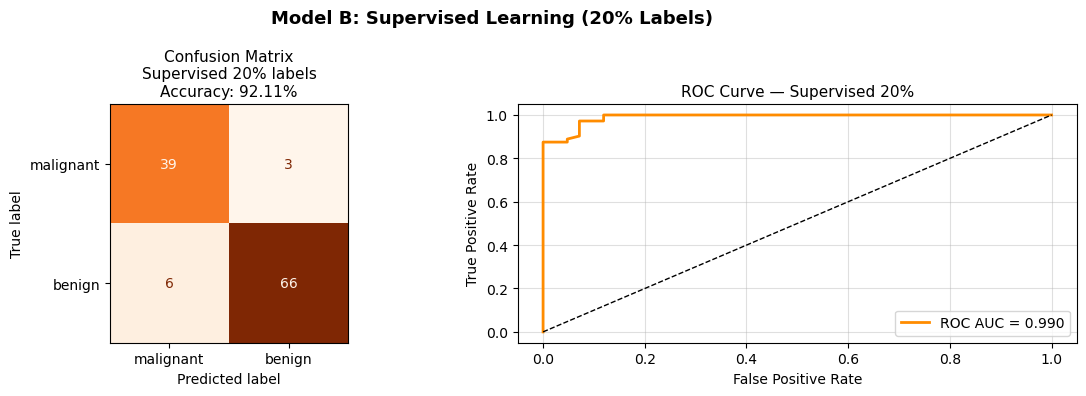

In [11]:
# --- Visualise ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_sup20 = confusion_matrix(y_test, y_pred_sup20)
disp     = ConfusionMatrixDisplay(cm_sup20, display_labels=data.target_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title(f"Confusion Matrix\nSupervised 20% labels\n"
                  f"Accuracy: {acc_sup20*100:.2f}%", fontsize=11)

fpr, tpr, _ = roc_curve(y_test, y_proba_sup20)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — Supervised 20%", fontsize=11)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.4)

plt.suptitle("Model B: Supervised Learning (20% Labels)", fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# ============================================================
# MODEL C: SELF-TRAINING — SEMI-SUPERVISED (20% labels)
# ============================================================
# ============================================================
print("=" * 60)
print("MODEL C: SELF-TRAINING — SEMI-SUPERVISED (20% labels)")
print("=" * 60)

# Same 20% limited labels — but now pass ALL data (labelled + unlabelled=-1)
# SelfTrainingClassifier will iteratively assign pseudo-labels
base_rf_st = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)

stc_20 = SelfTrainingClassifier(
    base_estimator = base_rf_st,
    threshold      = 0.80,    # accept pseudo-label only if confidence >= 80%
    verbose        = True     # show iteration progress
)

# --- Train ---
stc_20.fit(X_train_scaled, y_limited_20)

# --- Evaluate ---
y_pred_semi20  = stc_20.predict(X_test_scaled)
y_proba_semi20 = stc_20.predict_proba(X_test_scaled)[:, 1]
acc_semi20     = accuracy_score(y_test, y_pred_semi20)
print_metrics(y_test, y_pred_semi20, "Self-Training — 20% labels")

MODEL C: SELF-TRAINING — SEMI-SUPERVISED (20% labels)
End of iteration 1, added 310 new labels.
End of iteration 2, added 12 new labels.
End of iteration 3, added 4 new labels.
End of iteration 4, added 1 new labels.

--- Self-Training — 20% labels ---
              precision    recall  f1-score   support

   malignant       0.89      0.95      0.92        42
      benign       0.97      0.93      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



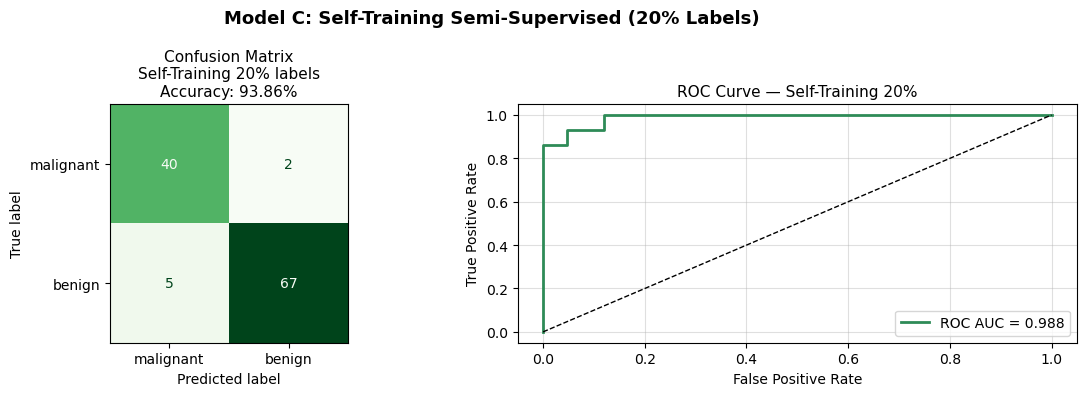

In [13]:
# --- Visualise ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_semi20 = confusion_matrix(y_test, y_pred_semi20)
disp      = ConfusionMatrixDisplay(cm_semi20, display_labels=data.target_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title(f"Confusion Matrix\nSelf-Training 20% labels\n"
                  f"Accuracy: {acc_semi20*100:.2f}%", fontsize=11)

fpr, tpr, _ = roc_curve(y_test, y_proba_semi20)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='seagreen', lw=2,
             label=f'ROC AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve — Self-Training 20%", fontsize=11)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.4)

plt.suptitle("Model C: Self-Training Semi-Supervised (20% Labels)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# ============================================================
# MODEL D: SELF-TRAINING — SEMI-SUPERVISED (10% labels)
# ============================================================
# ============================================================
print("=" * 60)
print("MODEL D: SELF-TRAINING — SEMI-SUPERVISED (10% labels)")
print("=" * 60)

y_limited_10   = create_limited_labels(y_train, 0.10)

base_rf_10 = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
stc_10     = SelfTrainingClassifier(
    base_estimator = base_rf_10,
    threshold      = 0.80,
    verbose        = False
)

# --- Train ---
stc_10.fit(X_train_scaled, y_limited_10)

# --- Evaluate ---
y_pred_semi10  = stc_10.predict(X_test_scaled)
y_proba_semi10 = stc_10.predict_proba(X_test_scaled)[:, 1]
acc_semi10     = accuracy_score(y_test, y_pred_semi10)
print_metrics(y_test, y_pred_semi10, "Self-Training — 10% labels")

MODEL D: SELF-TRAINING — SEMI-SUPERVISED (10% labels)

--- Self-Training — 10% labels ---
              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



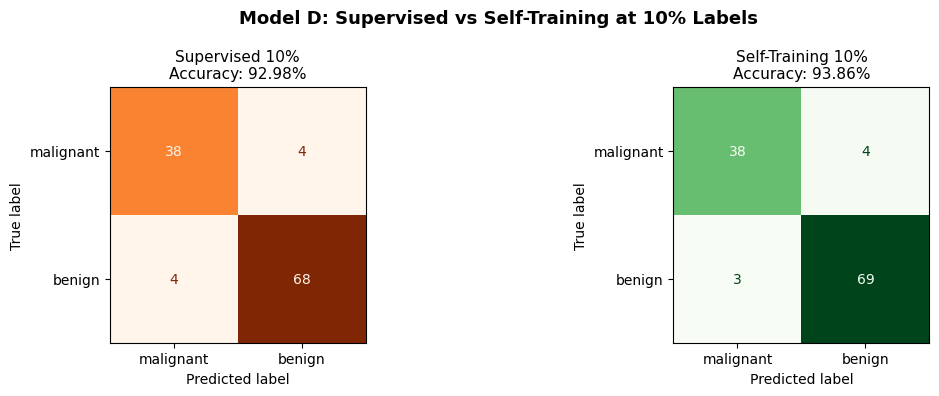

In [15]:
# --- Supervised baseline at 10% for comparison ---
y_limited_10b    = create_limited_labels(y_train, 0.10)
labelled_mask_10 = y_limited_10b != -1
rf_sup10         = RandomForestClassifier(n_estimators=100,
                                           random_state=RANDOM_STATE)
rf_sup10.fit(X_train_scaled[labelled_mask_10],
             y_limited_10b[labelled_mask_10])
y_pred_sup10  = rf_sup10.predict(X_test_scaled)
y_proba_sup10 = rf_sup10.predict_proba(X_test_scaled)[:, 1]
acc_sup10     = accuracy_score(y_test, y_pred_sup10)

# --- Visualise: side-by-side confusion matrices ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_sup10 = confusion_matrix(y_test, y_pred_sup10)
disp     = ConfusionMatrixDisplay(cm_sup10, display_labels=data.target_names)
disp.plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title(f"Supervised 10%\nAccuracy: {acc_sup10*100:.2f}%",
                  fontsize=11)

cm_semi10 = confusion_matrix(y_test, y_pred_semi10)
disp      = ConfusionMatrixDisplay(cm_semi10, display_labels=data.target_names)
disp.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f"Self-Training 10%\nAccuracy: {acc_semi10*100:.2f}%",
                  fontsize=11)

plt.suptitle("Model D: Supervised vs Self-Training at 10% Labels",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# ============================================================
# SECTION 6: FULL COMPARISON — ALL SCENARIOS
# ============================================================
# ============================================================
print("=" * 60)
print("FULL COMPARISON: ALL LABEL FRACTIONS")
print("=" * 60)

label_fractions = [1.0, 0.50, 0.20, 0.10]
results         = []

for frac in label_fractions:
    y_lim     = create_limited_labels(y_train, frac)
    lbl_mask  = y_lim != -1

    # Supervised
    rf_s = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    rf_s.fit(X_train_scaled[lbl_mask], y_lim[lbl_mask])
    acc_s = accuracy_score(y_test, rf_s.predict(X_test_scaled))

    # Semi-supervised
    rf_ss = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    stc   = SelfTrainingClassifier(base_estimator=rf_ss,
                                   threshold=0.80, verbose=False)
    stc.fit(X_train_scaled, y_lim)
    acc_ss = accuracy_score(y_test, stc.predict(X_test_scaled))

    results.append({
        "Label %"         : f"{int(frac*100)}%",
        "Supervised"      : round(acc_s  * 100, 2),
        "Self-Training"   : round(acc_ss * 100, 2),
        "Improvement"     : round((acc_ss - acc_s) * 100, 2)
    })
    print(f"  {int(frac*100):3d}% →  Sup: {acc_s*100:.2f}%  |  "
          f"Semi: {acc_ss*100:.2f}%  |  Δ: {(acc_ss-acc_s)*100:+.2f}%")

# --- Results Table ---
results_df = pd.DataFrame(results)
print("\nRESULTS TABLE")
print(results_df.to_string(index=False))

FULL COMPARISON: ALL LABEL FRACTIONS
  100% →  Sup: 95.61%  |  Semi: 95.61%  |  Δ: +0.00%
   50% →  Sup: 93.86%  |  Semi: 94.74%  |  Δ: +0.88%
   20% →  Sup: 92.11%  |  Semi: 93.86%  |  Δ: +1.75%
   10% →  Sup: 92.98%  |  Semi: 93.86%  |  Δ: +0.88%

RESULTS TABLE
Label %  Supervised  Self-Training  Improvement
   100%       95.61          95.61         0.00
    50%       93.86          94.74         0.88
    20%       92.11          93.86         1.75
    10%       92.98          93.86         0.88


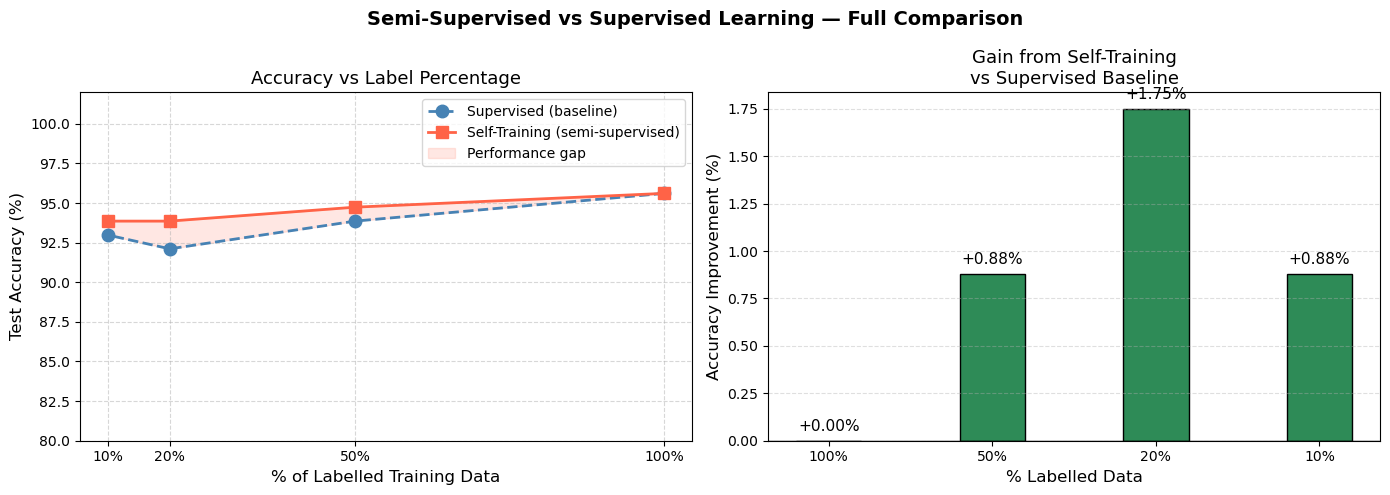

In [17]:
# ============================================================
# SECTION 7: MAIN COMPARISON GRAPH
# ============================================================
label_pcts = [int(r["Label %"].replace("%", "")) for r in results]
sup_accs   = [r["Supervised"]    for r in results]
semi_accs  = [r["Self-Training"] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: accuracy vs label % ---
axes[0].plot(label_pcts, sup_accs,
             marker='o', linestyle='--', color='steelblue',
             lw=2, markersize=9, label='Supervised (baseline)')
axes[0].plot(label_pcts, semi_accs,
             marker='s', linestyle='-', color='tomato',
             lw=2, markersize=9, label='Self-Training (semi-supervised)')
axes[0].fill_between(label_pcts, sup_accs, semi_accs,
                     alpha=0.15, color='tomato', label='Performance gap')
axes[0].set_xlabel("% of Labelled Training Data", fontsize=12)
axes[0].set_ylabel("Test Accuracy (%)", fontsize=12)
axes[0].set_title("Accuracy vs Label Percentage", fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_xticks(label_pcts)
axes[0].set_xticklabels([f"{p}%" for p in label_pcts])
axes[0].set_ylim(80, 102)

# --- Right: bar chart of improvements ---
improvements = [r["Improvement"] for r in results]
colors       = ['seagreen' if v >= 0 else 'tomato' for v in improvements]
axes[1].bar([r["Label %"] for r in results], improvements,
            color=colors, edgecolor='black', width=0.4)
axes[1].axhline(0, color='black', lw=1)
axes[1].set_xlabel("% Labelled Data", fontsize=12)
axes[1].set_ylabel("Accuracy Improvement (%)", fontsize=12)
axes[1].set_title("Gain from Self-Training\nvs Supervised Baseline",
                  fontsize=13)
axes[1].grid(True, linestyle='--', alpha=0.4, axis='y')
for i, v in enumerate(improvements):
    axes[1].text(i, v + 0.05, f"{v:+.2f}%", ha='center', fontsize=11)

plt.suptitle("Semi-Supervised vs Supervised Learning — Full Comparison",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

THRESHOLD SENSITIVITY (20% labels)
  Threshold 0.60  →  Accuracy: 94.74%
  Threshold 0.70  →  Accuracy: 92.98%
  Threshold 0.80  →  Accuracy: 93.86%
  Threshold 0.90  →  Accuracy: 92.11%
  Threshold 0.95  →  Accuracy: 92.11%


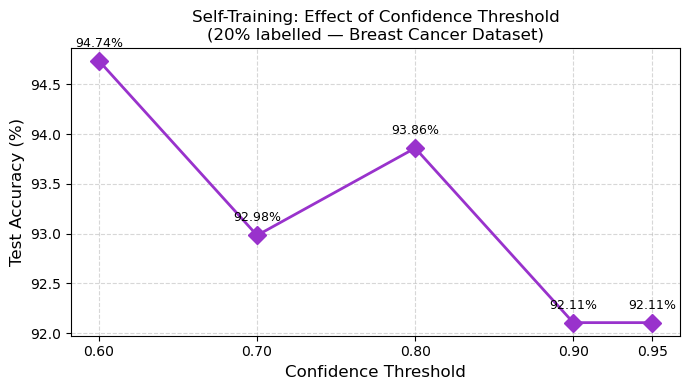

In [19]:
# ============================================================
# SECTION 8: THRESHOLD SENSITIVITY 
# ============================================================
print("=" * 60)
print("THRESHOLD SENSITIVITY (20% labels)")
print("=" * 60)

thresholds    = [0.60, 0.70, 0.80, 0.90, 0.95]
thresh_accs   = []
y_lim_thr     = create_limited_labels(y_train, 0.20)

for thresh in thresholds:
    rf_t  = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    stc_t = SelfTrainingClassifier(base_estimator=rf_t,
                                   threshold=thresh, verbose=False)
    stc_t.fit(X_train_scaled, y_lim_thr)
    acc_t = accuracy_score(y_test, stc_t.predict(X_test_scaled)) * 100
    thresh_accs.append(acc_t)
    print(f"  Threshold {thresh:.2f}  →  Accuracy: {acc_t:.2f}%")

plt.figure(figsize=(7, 4))
plt.plot(thresholds, thresh_accs,
         marker='D', color='darkorchid', lw=2, markersize=9)
for x, y_val in zip(thresholds, thresh_accs):
    plt.annotate(f"{y_val:.2f}%", (x, y_val),
                 textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=9)
plt.xlabel("Confidence Threshold", fontsize=12)
plt.ylabel("Test Accuracy (%)", fontsize=12)
plt.title("Self-Training: Effect of Confidence Threshold\n"
          "(20% labelled — Breast Cancer Dataset)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(thresholds)
plt.tight_layout()
plt.show()

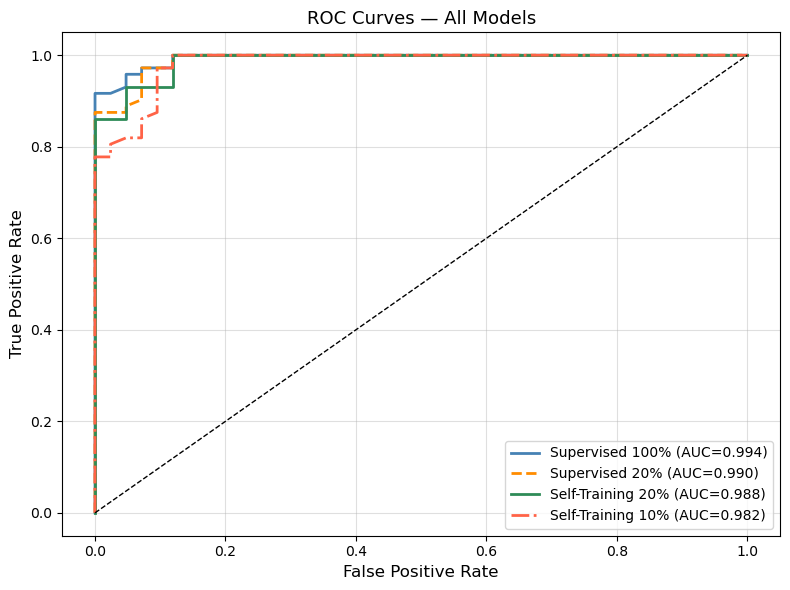

In [20]:
# ============================================================
# SECTION 9: ROC CURVE — ALL MODELS TOGETHER
# ============================================================
plt.figure(figsize=(8, 6))

# Full supervised
fpr, tpr, _ = roc_curve(y_test, rf_full.predict_proba(X_test_scaled)[:, 1])
plt.plot(fpr, tpr, lw=2, color='steelblue',
         label=f'Supervised 100% (AUC={auc(fpr,tpr):.3f})')

# Supervised 20%
fpr, tpr, _ = roc_curve(y_test, y_proba_sup20)
plt.plot(fpr, tpr, lw=2, color='darkorange', linestyle='--',
         label=f'Supervised 20% (AUC={auc(fpr,tpr):.3f})')

# Self-training 20%
fpr, tpr, _ = roc_curve(y_test, y_proba_semi20)
plt.plot(fpr, tpr, lw=2, color='seagreen',
         label=f'Self-Training 20% (AUC={auc(fpr,tpr):.3f})')

# Self-training 10%
fpr, tpr, _ = roc_curve(y_test, y_proba_semi10)
plt.plot(fpr, tpr, lw=2, color='tomato', linestyle='-.',
         label=f'Self-Training 10% (AUC={auc(fpr,tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — All Models", fontsize=13)
plt.legend(fontsize=10, loc='lower right')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()